# Análisis de Ventas — Tienda de Ropa Online
**Contexto del analisis:** El siguiente es un analisis de la tienda de ropa "Vesper": https://vesper.tiendanegocio.com/

**Objetivo:** identificar qué productos, categorías, talles y regiones impulsan las ventas, y detectar patrones de variación mensual para apoyar decisiones de stock y marketing.

**Fuente de datos:** exportación de ventas de la plataforma de e-commerce "Tiendanegocio" (marzo 2025 – septiembre 2026). Los datos personales de compradores (nombre, email, teléfono, dirección) fueron removidos por privacidad en la limpieza de los datos antes de este análisis.

**Preguntas de negocio:**
1. ¿Cómo evolucionaron las ventas de productos mes a mes? ¿Hay evidencia de estacionalidad?
2. ¿Qué categorías y diseños puntuales generan más ingresos y unidades vendidas?
3. ¿De qué provincias/ciudades son los clientes y cómo se distribuyen las ventas?
4. ¿Qué talles rotan más?
5. ¿Qué diferencias hay entre Buenos Aires/CABA y el resto del país?
6. ¿Cuál es el ticket promedio y cómo se compone?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('ventas_limpio_confirmadas.csv', parse_dates=['Fecha'])
df.head()

,# de venta,Fecha,Hora,Estado de la venta,Subtotal de productos,Descuento,Costo de envío,Total,Metódo de envío,Código postal,...,Cupón de decuento,Nombre del producto,Precio del producto,Cantidad del producto,SKU,Mes,Categoria,Talle,Total_linea,Diseño
0,1,2025-03-12,14:38,Pago Confirmado,16900.0,0.0,4901.0,21801.0,Correo Argentino - Retiro por sucursal,9400.0,...,NaN,"Remera ""Jeff"" (Negro) (M)",16900,1,P1265950,2025-03,Remera,M,16900.0,Remera Jeff
1,2,2025-03-12,20:11,Pago Confirmado,33800.0,-3380.0,3818.0,34238.0,Correo Argentino - Retiro por sucursal,1123.0,...,JEFF,"Remera ""Jeff"" (Blanco) (L)",16900,1,P1265950,2025-03,Remera,L,15210.0,Remera Jeff
2,2,2025-03-12,20:11,Pago Confirmado,33800.0,-3380.0,3818.0,34238.0,Correo Argentino - Retiro por sucursal,1123.0,...,JEFF,"Remera ""experimento ruso"" (Negro) (L)",16900,1,P1272608,2025-03,Remera,L,15210.0,Remera experimento ruso
3,3,2025-03-12,20:17,Pago Confirmado,27300.0,-2730.0,3704.0,28274.0,Correo Argentino - Retiro por sucursal,1759.0,...,JEFF,"Baby tee ""Jeff"" (Negro) (M)",10400,1,P1265986,2025-03,Baby Tee,M,9360.0,Baby tee Jeff
4,3,2025-03-12,20:17,Pago Confirmado,27300.0,-2730.0,3704.0,28274.0,Correo Argentino - Retiro por sucursal,1759.0,...,JEFF,"Remera ""experimento ruso"" (Negro) (XL)",16900,1,P1272608,2025-03,Remera,XL,15210.0,Remera experimento ruso


## 1. Overview del dataset

In [2]:
print(f"Filas (líneas de producto): {df.shape[0]}")
print(f"Ventas únicas: {df['# de venta'].nunique()}")
print(f"Rango de fechas: {df['Fecha'].min().date()} a {df['Fecha'].max().date()}")
print(f"Ventas netas de productos: ${df['Total_linea'].sum():,.0f}")
print(f"Pedidos con costo de envío faltante: {df.groupby('# de venta')['Costo de envío'].first().isna().sum()}")

Filas (líneas de producto): 285
Ventas únicas: 201
Rango de fechas: 2025-03-12 a 2026-09-10
Ventas netas de productos: $4,774,368
Pedidos con costo de envío faltante: 6


El archivo utilizado en este EDA ya contiene únicamente ventas con estado **"Pago Confirmado"**. Por lo tanto, los estados "Archivado" y "Pago Pendiente" fueron excluidos durante la etapa de limpieza, antes de este notebook.

En este análisis, Ventas netas de productos se refiere a `Total_linea`, que suma el importe de cada línea de producto después de descuentos y no incluye el costo de envío. Para analizar el importe finalmente cobrado al cliente se utiliza `Total`.

**Cobertura temporal:** el último registro es del 10 de septiembre de 2026, por lo que septiembre de 2026 es un mes parcial y no se compara directamente con meses completos. Además, no hay datos de febrero de 2025 porque el emprendimiento comenzó en marzo de 2025.

## 2. Evolución mensual de ingresos

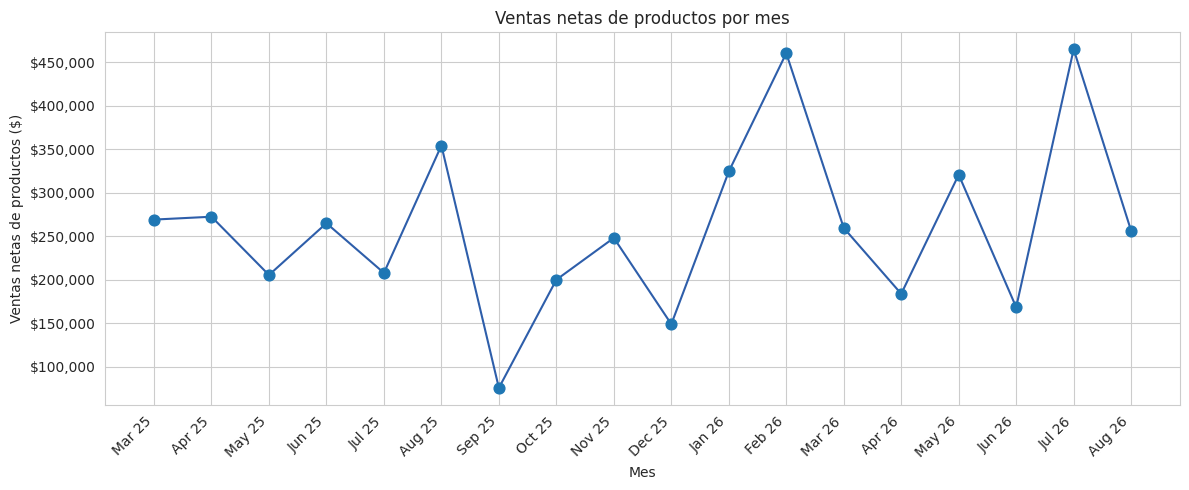

In [3]:
ventas_mes = df.groupby('Mes')['Total_linea'].sum().sort_index()
ventas_mes = ventas_mes.drop('2026-09', errors='ignore')
labels = pd.to_datetime(ventas_mes.index).strftime('%b %y')
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(labels, ventas_mes.values, color='#2E5EAA', linewidth=1.5, zorder=1)
ax.scatter(labels, ventas_mes.values, s=60, zorder=2)
ax.set_title('Ventas netas de productos por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas netas de productos ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Los mayores niveles de ventas netas de productos del período se registran en julio de 2026 y febrero de 2026. También se destacan agosto de 2025, enero de 2026 y mayo de 2026.

El mínimo entre los meses completos es septiembre de 2025. Septiembre de 2026 se excluye del gráfico porque el período llega solo hasta el día 10.

Hay una variación mensual clara, pero con un solo ciclo anual completo y un segundo ciclo parcial no alcanza para afirmar una estacionalidad anual consolidada. Febrero de 2025 tampoco está disponible para una comparación interanual completa.

## 3. Categorías y diseños que más venden

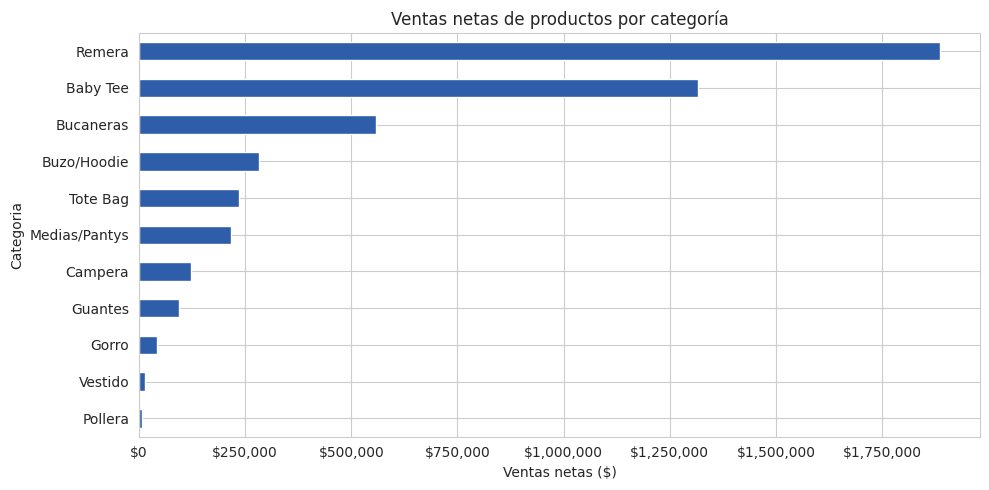

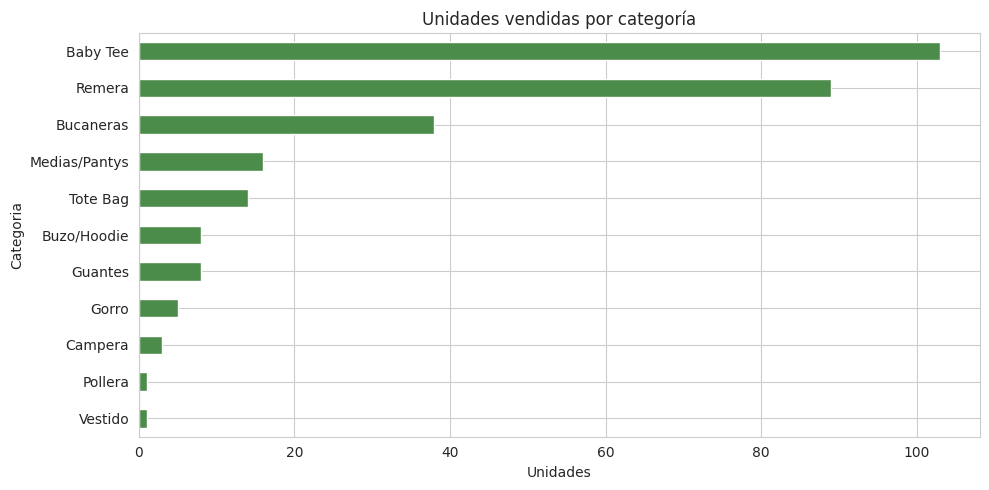

In [4]:
ingresos_cat = df.groupby('Categoria')['Total_linea'].sum().sort_values(ascending=False)
unidades_cat = df.groupby('Categoria')['Cantidad del producto'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ingresos_cat.sort_values().plot(kind='barh', ax=ax, color='#2E5EAA')
ax.set_title('Ventas netas de productos por categoría')
ax.set_xlabel('Ventas netas ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
unidades_cat.sort_values().plot(kind='barh', ax=ax, color='#4C8C4A')
ax.set_title('Unidades vendidas por categoría')
ax.set_xlabel('Unidades')
plt.tight_layout()
plt.show()

Por ventas netas de productos,Remera es la categoría principal: (**39,5%**) del total, seguida por **Baby Tee** (**27,6%**). En conjunto, ambas concentran **67,1%** de las ventas netas de productos.

Por unidades, en cambio, **Baby Tee registra 103 unidades** y Remera **89**. Esto muestra que la categoría que lidera en facturación no necesariamente lidera en cantidad de unidades.

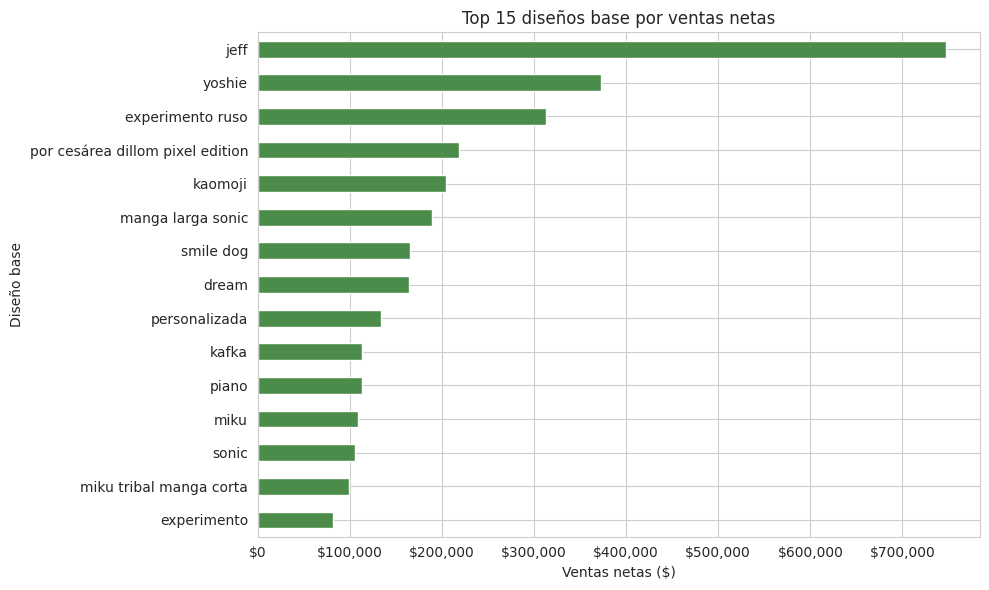

In [5]:

prefijos_categoria = r'^(baby tee|remera|bucaneras|buzo(?:/hoodie)?|tote bag|totebag|guantes|gorro|campera|medias/pantys|medias|pantys|vestido|pollera)\s+'
df['Diseño base'] = (
    df['Diseño']
      .fillna('Sin diseño')
      .str.strip()
      .str.lower()
      .str.replace(prefijos_categoria, '', regex=True)
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
)

top_disenos = (
    df.groupby('Diseño base')
      .agg(ventas_netas=('Total_linea', 'sum'), unidades=('Cantidad del producto', 'sum'))
      .sort_values('ventas_netas', ascending=False)
      .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_disenos['ventas_netas'].sort_values().plot(kind='barh', ax=ax, color='#4C8C4A')
ax.set_title('Top 15 diseños base por ventas netas')
ax.set_xlabel('Ventas netas ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

Al agrupar el nombre del diseño y quitar el prefijo de la categoría, **Jeff** queda como el diseño base con mayor facturación.

## 4. Distribución geográfica

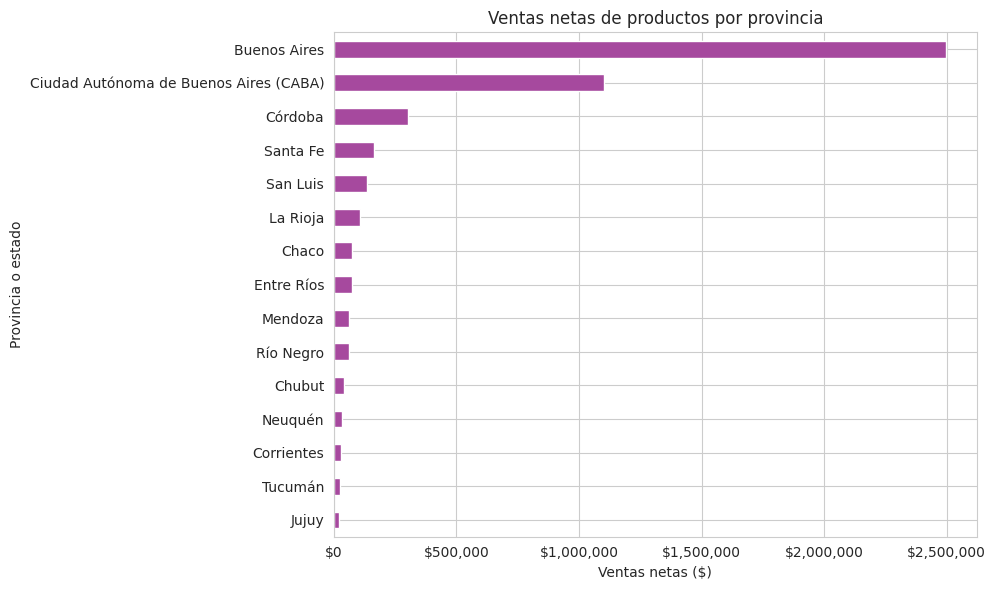

In [6]:
ventas_prov = df.groupby('Provincia o estado')['Total_linea'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ventas_prov.sort_values().plot(kind='barh', ax=ax, color='#A6499E')
ax.set_title('Ventas netas de productos por provincia')
ax.set_xlabel('Ventas netas ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

Hay una concentración fuerte de ventas en **Buenos Aires y CABA**. Para analizar si el costo de envío ayuda a explicar las diferencias, a continuacion se muestra en el grafico si existe relacion entre costo de envio y ticket promedio:

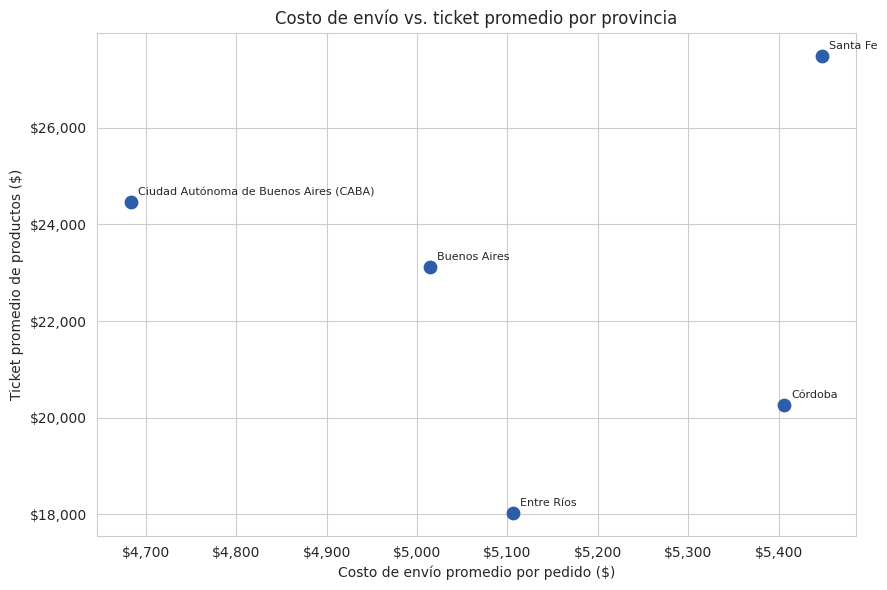


Provincias con al menos 4 pedidos:


,ventas_netas,ticket_productos,envio_promedio,pedidos
Provincia,,,,
Buenos Aires,2498046.0,23130.0,5014.0,108
Ciudad Autónoma de Buenos Aires (CABA),1100986.0,24466.0,4684.0,45
Córdoba,303920.0,20261.0,5406.0,15
Santa Fe,164970.0,27495.0,5448.0,6
Entre Ríos,72075.0,18019.0,5106.0,4


In [13]:
pedidos = (
    df.groupby('# de venta', as_index=False)
      .agg(
          Fecha=('Fecha', 'first'),
          Provincia=('Provincia o estado', 'first'),
          Ciudad=('Ciudad', 'first'),
          Subtotal=('Subtotal de productos', 'first'),
          Descuento=('Descuento', 'first'),
          Costo_envio=('Costo de envío', 'first'),
          Total=('Total', 'first'),
          Ventas_productos=('Total_linea', 'sum'),
          Unidades=('Cantidad del producto', 'sum')
      )
)
pedidos['Costo_envio_analisis'] = pedidos['Costo_envio']
mask_envio = pedidos['Costo_envio_analisis'].isna()
pedidos.loc[mask_envio, 'Costo_envio_analisis'] = (
    pedidos.loc[mask_envio, 'Total']
    - pedidos.loc[mask_envio, 'Subtotal']
    - pedidos.loc[mask_envio, 'Descuento']
)

envio_ingresos = (
    pedidos.groupby('Provincia')
    .agg(
        ventas_netas=('Ventas_productos', 'sum'),
        ticket_productos=('Ventas_productos', 'mean'),
        envio_promedio=('Costo_envio_analisis', 'mean'),
        pedidos=('# de venta', 'count')
    )
    .sort_values('ventas_netas', ascending=False)
)

muestra_confiable = envio_ingresos[envio_ingresos['pedidos'] >= 4].copy()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(muestra_confiable['envio_promedio'], muestra_confiable['ticket_productos'],
           color='#2E5EAA', s=80)

for prov, row in muestra_confiable.iterrows():
    ax.annotate(prov, (row['envio_promedio'], row['ticket_productos']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

ax.set_xlabel('Costo de envío promedio por pedido ($)')
ax.set_ylabel('Ticket promedio de productos ($)')
ax.set_title('Costo de envío vs. ticket promedio por provincia')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()



print("\nProvincias con al menos 4 pedidos:")
display(muestra_confiable.round(0))

El gráfico muestra **el ticket promedio de productos** frente al costo de envío promedio por provincia.
En estos datos no aparece una relación descriptiva fuerte que permita explicar las diferencias de facturación entre provincias únicamente por el costo de envío. Esto no demuestra causalidad ni ausencia de efecto: para evaluarlo mejor habría que incorporar volumen de pedidos, distancia o zona logística, promociones y otras variables.

In [8]:
ventas_unicas = pedidos.copy()
ventas_unicas['Zona'] = ventas_unicas['Provincia'].isin(
    ['Buenos Aires', 'Ciudad Autónoma de Buenos Aires (CABA)']
).map({True: 'Buenos Aires/CABA', False: 'Resto del país'})

comparacion_zona = ventas_unicas.groupby('Zona').agg(
    pedidos=('# de venta', 'count'),
    subtotal_promedio=('Subtotal', 'mean'),
    envio_promedio=('Costo_envio_analisis', 'mean'),
    total_promedio=('Total', 'mean'),
    unidades_promedio=('Unidades', 'mean'),
).round(2)

comparacion_zona

,pedidos,subtotal_promedio,envio_promedio,total_promedio,unidades_promedio
Zona,,,,,
Buenos Aires/CABA,153,24626.58,4917.13,28440.22,1.39
Resto del país,48,25539.58,5742.23,30228.38,1.52


Los pedidos del **resto del país** tienen, en promedio, **1,52 unidades por pedido**, frente a **1,39** en Buenos Aires/CABA: la diferencia es de aproximadamente **9,4%**.

También presentan un ticket total promedio mayor y un costo de envío promedio mayor. Estos datos describen una diferencia entre zonas, pero no permiten afirmar que la causa sea el costo de envío.

## 5. Talles

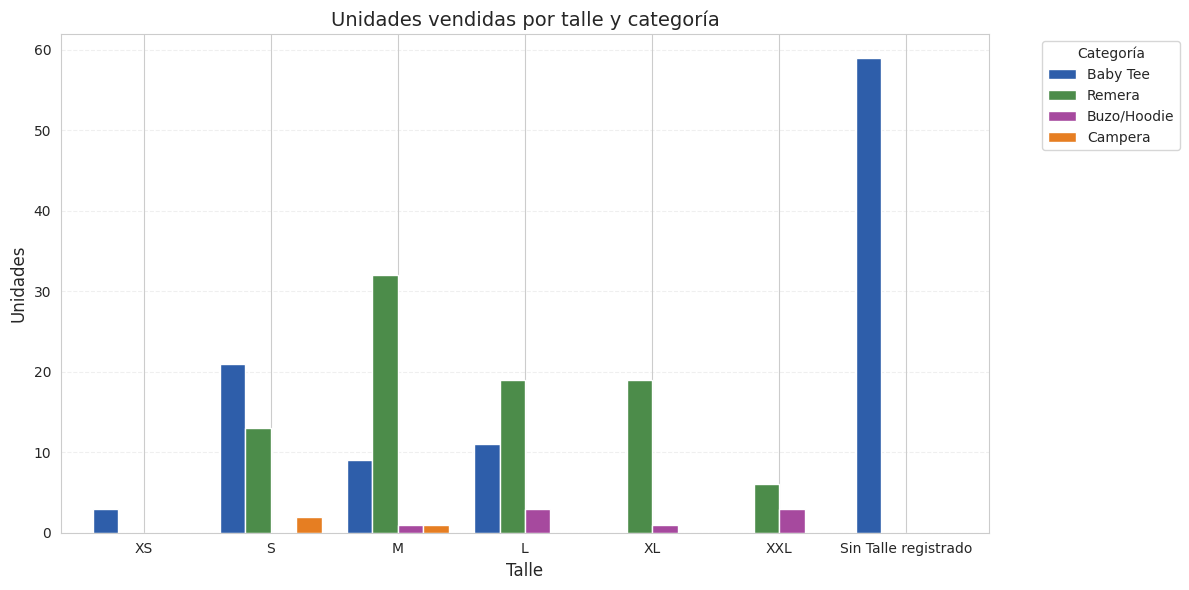

,lineas,con_talle,cobertura_%
Categoria,,,
Baby Tee,103,44,42.7
Remera,89,89,100.0
Guantes,8,0,0.0
Buzo/Hoodie,8,8,100.0
Gorro,5,0,0.0
Campera,3,3,100.0
Pollera,1,0,0.0
Vestido,1,0,0.0


In [14]:
import re

dfc_talle_completo = df.copy()

categorias_a_excluir = ['Bucaneras', 'Tote Bag', 'Medias/Pantys']
dfc_talle_completo = dfc_talle_completo[~dfc_talle_completo['Categoria'].isin(categorias_a_excluir)].copy()

talle_desde_nombre = (
    dfc_talle_completo['Nombre del producto']
    .str.extract(r'(?:^|[\s(])(XXL|XL|XS|L|M|S)(?=$|[\s)])', flags=re.I, expand=False)
    .str.upper()
)
dfc_talle_completo['Talle_analisis'] = dfc_talle_completo['Talle'].fillna(talle_desde_nombre)
dfc_talle_completo['Talle_analisis'] = dfc_talle_completo['Talle_analisis'].fillna('Sin Talle registrado')

cats_interes = ['Baby Tee', 'Remera', 'Buzo/Hoodie', 'Campera']
disponibles = [c for c in cats_interes if c in dfc_talle_completo['Categoria'].unique()]

unidades_talle_categoria = (
    dfc_talle_completo.groupby(['Talle_analisis', 'Categoria'])['Cantidad del producto']
    .sum().unstack(fill_value=0)
)
unidades_talle_categoria = unidades_talle_categoria.reindex(columns=disponibles, fill_value=0)

talles_orden = ['XS', 'S', 'M', 'L', 'XL', 'XXL', 'Sin Talle registrado']
talles_existentes = [t for t in talles_orden if t in unidades_talle_categoria.index]
unidades_talle_categoria = unidades_talle_categoria.reindex(talles_existentes)

fig, ax = plt.subplots(figsize=(12, 6))
colores = ['#2E5EAA', '#4C8C4A', '#A6499E', '#E67E22']
unidades_talle_categoria.plot(kind='bar', ax=ax, width=0.8, color=colores[:len(disponibles)])

ax.set_title('Unidades vendidas por talle y categoría', fontsize=14)
ax.set_xlabel('Talle', fontsize=12)
ax.set_ylabel('Unidades', fontsize=12)
ax.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

resumen_talles = (
    dfc_talle_completo.groupby('Categoria')
    .agg(lineas=('Categoria', 'size'),
         con_talle=('Talle_analisis', lambda s: s.ne('Sin Talle registrado').sum()))
)
resumen_talles['cobertura_%'] = (100 * resumen_talles['con_talle'] / resumen_talles['lineas']).round(1)
resumen_talles.sort_values('lineas', ascending=False)

El talle no viene en una columna propia en el export original y se puede inferir solamente cuando el nombre del producto contiene un formato reconocible. En este EDA se complementa la columna `Talle` buscando explícitamente XS, S, M, L, XL y XXL en el nombre cuando falta el dato.

Con este criterio, **Remera tiene 100% de cobertura de talle y Baby Tee 42,7%**. Por eso, la rotación por talle de Baby Tee debe interpretarse con cautela: una parte importante de sus ventas sigue sin talle identificable. Los valores 1, 2, 3 y 4 presentes en algunos nombres no se interpretan como talles.

## 6. Ticket promedio y composición

Ticket promedio total: $28,867
  Subtotal de productos: $24,845
  Descuento promedio: $-1,092
  Costo de envío promedio: $5,114


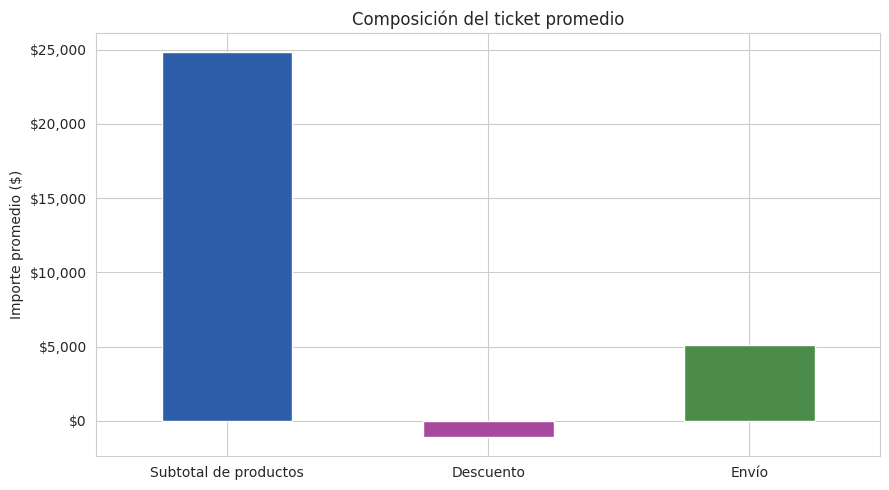

In [10]:
ticket_promedio = pedidos[['Subtotal', 'Descuento', 'Costo_envio_analisis', 'Total']].mean()

print(f"Ticket promedio total: ${ticket_promedio['Total']:,.0f}")
print(f"  Subtotal de productos: ${ticket_promedio['Subtotal']:,.0f}")
print(f"  Descuento promedio: ${ticket_promedio['Descuento']:,.0f}")
print(f"  Costo de envío promedio: ${ticket_promedio['Costo_envio_analisis']:,.0f}")

componentes_ticket = pd.Series({
    'Subtotal de productos': ticket_promedio['Subtotal'],
    'Descuento': ticket_promedio['Descuento'],
    'Envío': ticket_promedio['Costo_envio_analisis']
})

fig, ax = plt.subplots(figsize=(9, 5))
componentes_ticket.plot(kind='bar', ax=ax, color=['#2E5EAA', '#A6499E', '#4C8C4A'])
ax.set_title('Composición del ticket promedio')
ax.set_ylabel('Importe promedio ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El ticket promedio en bruto es de 28.867. Se compone, en promedio, de 24.845 de subtotal de productos,-1.092 de descuento* y 5.114 de envío, el ticket promedio neto es de 23.753 (24.845 - 1.092 = 23.75)




# **Insights clave:**
1. **Categorías:** Remera y Baby Tee concentran el **67,1%** de las ventas netas de productos. Remera lidera en facturación, mientras Baby Tee lidera en unidades vendidas.
2. **Diseño:** al agrupar variantes por diseño base, **Jeff** es el diseño con mayor facturación.
3. **Geografía:** Buenos Aires/CABA concentran la mayor parte de los pedidos y ventas. Fuera de Buenos Aires/CABA se observan **1,52 unidades por pedido vs. 1,39**, una diferencia de aproximadamente **9,4%**. El análisis por provincia no muestra evidencia descriptiva suficiente para atribuir las diferencias de ventas al costo de envío.
4. **Talles:** Remera tiene **100%** de cobertura de talle y Baby Tee **42,7%** después de complementar talles explícitos presentes en algunos nombres de producto. La cobertura incompleta de Baby Tee limita la confiabilidad de cualquier conclusión sobre rotación por talle.
5. **Ticket:** el ticket promedio total es de 28.867, compuesto por 24.845 de subtotal de productos, -1.092 de descuentos y 5.114 de envío.
6. **Datos temporales:** julio de 2026 y febrero de 2026 son los meses de mayores ventas netas del período, septiembre de 2026 es parcial y no se utiliza para comparar meses completos. Con la cobertura disponible no alcanza para afirmar una estacionalidad anual consolidada.